[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO26 Object Detection on a Custom Dataset

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mr-mph/ground-school/blob/main/yolo-tutorial/train_yolo26_object_detection_on_custom_dataset.ipynb)
[![Ultralytics Docs](https://img.shields.io/badge/docs-ultralytics-blue)](https://docs.ultralytics.com/models/yolo26/)
[![Roboflow Docs](https://img.shields.io/badge/docs-roboflow-purple)](https://docs.roboflow.com/)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

This is an updated version of Roboflow's classic *"How to Train YOLOv8 Object Detection on a Custom Dataset"* notebook.
It follows the same steps, but uses the current SDKs and is tuned to run faster on a free Colab T4.

**What changed compared to the original YOLOv8 notebook**

| Area | Original (2023) | This notebook |
|---|---|---|
| Model | YOLOv8s (`ultralytics==8.2.103`) | **YOLO26s** (`ultralytics>=8.4`), NMS-free end-to-end head |
| Roboflow SDK | `roboflow==1.1.48` | `roboflow>=1.5` |
| Training entry point | `!yolo ...` shell commands | Python API. Every `!yolo` call re-imports PyTorch (10-20 s each on Colab). We load once and reuse the `YOLO` object |
| Data loading | default | `cache="ram"`, so the tiny 2-CPU Colab VM is not the bottleneck |
| API key | interactive prompt every run | Colab **Secrets** (falls back to the prompt) |
| Visualisation | save to disk, then re-read `.jpg` files | in-memory with [`supervision`](https://supervision.roboflow.com) |
| Hosted inference | `roboflow` model object | still the `roboflow` SDK. `inference-sdk` pins `pillow>=12.3`, which upgrades Colab's already-imported Pillow and breaks the runtime |
| Edge deployment | HTTP `requests` snippet with undefined variables | `inference` package, `inference-sdk` against a local server, or plain ONNX/TensorRT export |

## Pro Tip: Use GPU Acceleration

In Google Colab, go to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, choose a GPU (`T4` is free) and click `Save`.
Training on CPU works but takes 20-50x longer.

## Steps in this Tutorial

- Before you start
- Install the SDKs
- Inference with a pre-trained COCO model (CLI and Python)
- Roboflow Universe
- Preparing a custom dataset
- Custom training
- Validate the custom model
- Inference with the custom model
- Deploy the model on Roboflow
- Deploy the model to the edge

**Let's begin!**

## Before you start

Let's make sure we have a GPU. `nvidia-smi` prints the GPU name and how much memory it has.
If it fails, follow the *Pro Tip* above and re-run this cell.

In [1]:
!nvidia-smi

Mon Sep 28 16:41:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

HOME = os.getcwd()
print(HOME)

/content


## Install the SDKs

We install everything we need in one `pip` call. Colab already ships with PyTorch, so this takes well under a minute.

- [`ultralytics`](https://github.com/ultralytics/ultralytics): YOLO26 training, validation, prediction and export
- [`roboflow`](https://github.com/roboflow/roboflow-python): download datasets from and upload weights to Roboflow
- [`supervision`](https://github.com/roboflow/supervision): utilities for drawing and post-processing detections

We pin lower bounds only, so you always get the newest compatible release.

In [3]:
%pip install -q "ultralytics>=8.4" "roboflow>=1.5" "supervision>=0.30"

from IPython.display import clear_output
clear_output()

# Guard: if pip upgraded a package the kernel had already imported (Pillow is the
# usual suspect on Colab), the in-memory copy no longer matches the files on disk.
import sys
from importlib.metadata import version as installed_version

for dist, module in (("pillow", "PIL"), ("numpy", "numpy")):
    loaded = sys.modules.get(module)
    if loaded is not None and loaded.__version__ != installed_version(dist):
        raise RuntimeError(
            f"{dist} was upgraded on disk ({loaded.__version__} -> {installed_version(dist)}) "
            "while already imported. Go to Runtime -> Restart session, then re-run this cell."
        )

import ultralytics
from ultralytics import YOLO, settings

# Opt out of ultralytics usage analytics before anything else runs.
settings.update(sync=False)

ultralytics.checks()

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


## CLI Basics

If you just want to train, validate or predict without writing code, the `yolo` command line interface is the fastest way to get started.
Read more in the [Ultralytics CLI docs](https://docs.ultralytics.com/usage/cli/).

```
yolo task=detect    mode=train    model=yolo26n.yaml      args...
          classify       predict        yolo26n-cls.yaml  args...
          segment        val            yolo26n-seg.yaml  args...
          pose           export         yolo26n-pose.pt   format=onnx  args...
          obb            track          yolo26n-obb.pt
```

The rest of this notebook uses the Python API instead. It does exactly the same thing, but in a notebook it is much faster:
each `!yolo ...` shell command starts a fresh Python process and re-imports PyTorch, which costs 10-20 seconds every time on Colab.

## Inference with a Pre-trained COCO Model

YOLO26 ships with weights pre-trained on COCO (80 everyday classes). Let's try the smallest one, `yolo26n`, before we train anything.
Weights are downloaded automatically the first time you reference them.

### 💻 CLI

`yolo predict` runs inference on images, videos, directories, URLs or webcams and saves annotated results to `runs/detect/predict`.

In [4]:
%cd {HOME}
!yolo task=detect mode=predict model=yolo26n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

/content
Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs

image 1/1 /content/dog.jpeg: 640x384 1 person, 1 dog, 1 backpack, 9.4ms
Speed: 188.8ms preprocess, 9.4ms inference, 40.9ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


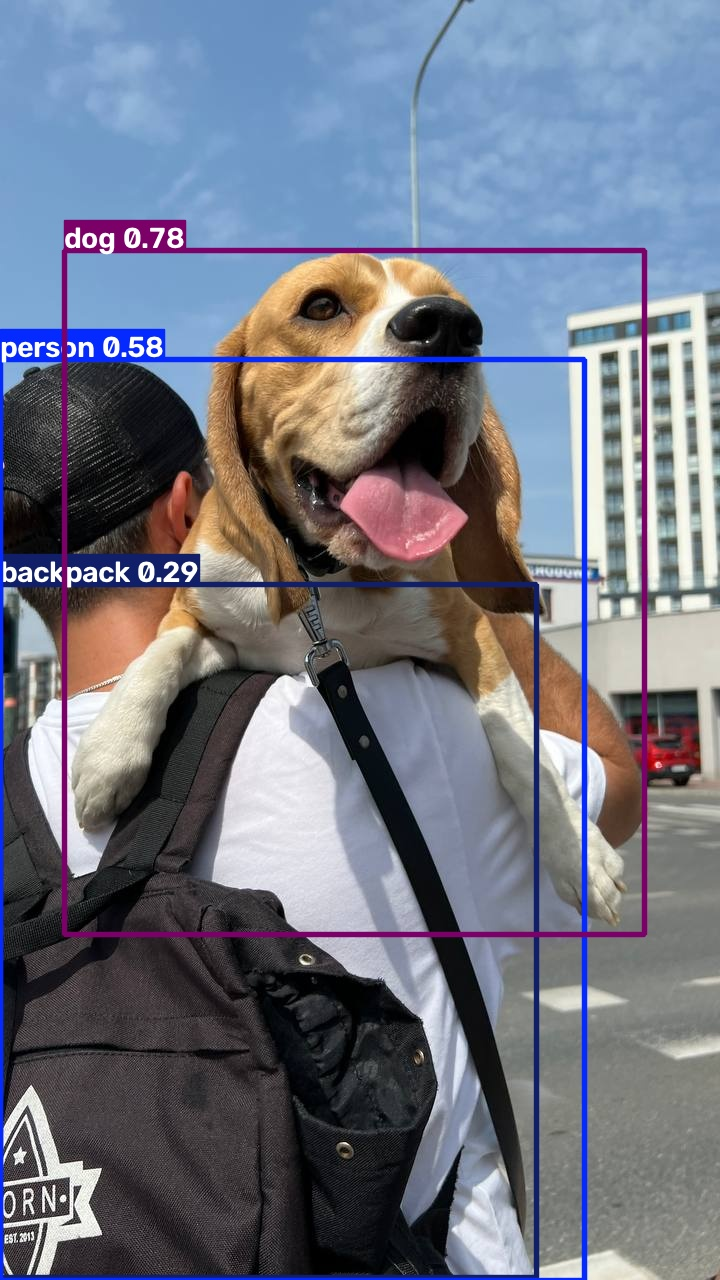

In [5]:
from IPython.display import Image, display

display(Image(filename=f"{HOME}/runs/detect/predict/dog.jpg", height=600))

### 🐍 Python SDK

The same thing in Python. Loading the model once and reusing it is what makes the rest of the notebook quick.

YOLO26 is *end-to-end*: it does not need Non-Maximum Suppression (NMS) after the network, so the `conf` threshold is the only post-processing knob you need.

In [6]:
model = YOLO("yolo26n.pt")

results = model.predict(
    source="https://media.roboflow.com/notebooks/examples/dog.jpeg",
    conf=0.25,
    verbose=False,
)
result = results[0]

Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg


Each `Result` holds the detections as tensors. `xyxy` are the box corners in pixels, `conf` the confidence, `cls` the class index, and `names` maps indices to labels.

In [7]:
print(result.boxes.xyxy)
print(result.boxes.conf)
print(result.boxes.cls)
print([result.names[int(c)] for c in result.boxes.cls])

tensor([[  64.3949,  250.0124,  644.6239,  934.7676],
        [   0.0000,  359.0189,  584.8723, 1280.0000],
        [   0.0000,  584.0991,  536.6089, 1277.0442]], device='cuda:0')
tensor([0.7836, 0.5764, 0.2891], device='cuda:0')
tensor([16.,  0., 24.], device='cuda:0')
['dog', 'person', 'backpack']


`supervision` gives us a `Detections` object that works the same way for every model (Ultralytics, Roboflow, Transformers, ...), plus annotators to draw them.
We will reuse this helper for the custom model later.

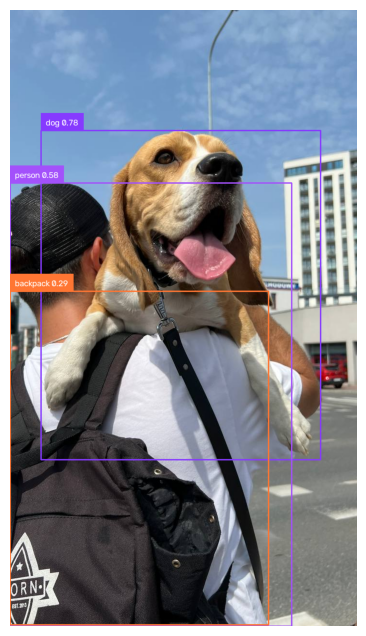

In [8]:
import supervision as sv

box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.6, text_thickness=1)


def annotate(result):
    """Draw boxes and labels from an Ultralytics Result onto a copy of its source image."""
    detections = sv.Detections.from_ultralytics(result)
    labels = [
        f"{name} {conf:.2f}"
        for name, conf in zip(detections["class_name"], detections.confidence)
    ]
    frame = result.orig_img.copy()
    frame = box_annotator.annotate(scene=frame, detections=detections)
    frame = label_annotator.annotate(scene=frame, detections=detections, labels=labels)
    return frame


sv.plot_image(annotate(result), size=(8, 8))

## Roboflow Universe

Need data for your project? Before spending time on annotating, check out [Roboflow Universe](https://universe.roboflow.com/), a repository of hundreds of thousands of open-source datasets and pre-trained models that you can use in your projects. You'll find datasets containing everything from annotated cracks in concrete to plant images with disease annotations.

[![Roboflow Universe](https://media.roboflow.com/notebooks/template/uni-banner-frame.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672878480290)](https://universe.roboflow.com/)

## Preparing a custom dataset

Building a custom dataset can be a painful process. It might take dozens or even hundreds of hours to collect images, label them, and export them in the proper format. Fortunately, Roboflow makes this process as straightforward and fast as possible.

### Step 1: Creating a project

Before you start, you need to create a Roboflow [account](https://app.roboflow.com/login). Once you do that, you can create a new project in the Roboflow [dashboard](https://app.roboflow.com/). Keep in mind to choose the right project type. In our case, Object Detection.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/creating-project.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929799852"
  >
</div>

### Step 2: Uploading images

Next, add the data to your newly created project. You can do it via API or through the [web interface](https://docs.roboflow.com/adding-data/object-detection).

If you drag and drop a directory with a dataset in a [supported format](https://roboflow.com/formats), the Roboflow dashboard will automatically read the images and annotations together.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/uploading-images.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929808290"
  >
</div>

### Step 3: Labeling

If you only have images, you can label them in [Roboflow Annotate](https://docs.roboflow.com/annotate). Auto Label and Label Assist can pre-annotate images for you using foundation models, so you only correct mistakes instead of drawing every box.

<div align="center">
  <img
    width="640"
    src="https://user-images.githubusercontent.com/26109316/210901980-04861efd-dfc0-4a01-9373-13a36b5e1df4.gif"
  >
</div>

### Step 4: Generate a new dataset version

Now that we have our images and annotations added, we can Generate a Dataset Version. When Generating a Version, you may elect to add preprocessing and augmentations. This step is completely optional, however, it can allow you to significantly improve the robustness of your model.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/generate-new-version.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1673003597834"
  >
</div>

### Step 5: Exporting the dataset

Once the dataset version is generated, we have a hosted dataset we can load directly into our notebook for easy training. Click `Export` and pick any of the **YOLOv8 / YOLOv11 / YOLOv12** formats. They all produce the same `images/` + `labels/*.txt` + `data.yaml` layout that YOLO26 trains on. Below we download it with the SDK instead of clicking through the UI.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/export.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672943313709"
  >
</div>

### Authenticate with Roboflow

Store your API key once in Colab **Secrets** (the 🔑 icon in the left sidebar) under the name `ROBOFLOW_API_KEY` and enable *Notebook access*.
Then you never have to paste it again, and it never ends up saved inside the notebook.

If the secret is missing (or you are not on Colab) we fall back to `roboflow.login()`, which opens an interactive prompt.
You can find your key at [app.roboflow.com/settings/api](https://app.roboflow.com/settings/api).

🟢 Tip: The example below uses a public dataset from Universe, so everything through *Inference with the custom model* works with any account.
To **deploy** the trained weights back to Roboflow you need a project in your own workspace: either fork (copy) the dataset from Universe into your workspace, or use one of your own projects, and change `WORKSPACE`, `PROJECT` and `VERSION` accordingly.

In [9]:
import roboflow
from roboflow import Roboflow

ROBOFLOW_API_KEY = None
try:
    from google.colab import userdata  # only exists on Colab

    ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
except Exception:
    pass

if ROBOFLOW_API_KEY:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
else:
    roboflow.login()  # interactive prompt, key is cached in ~/.config/roboflow
    rf = Roboflow()

### Download the dataset

`version.download()` pulls a zip, extracts it and returns a `dataset` object whose `.location` is the folder on disk.
We ask for the `yolov11` format. The label files are identical for YOLOv8, YOLOv11, YOLOv12 and YOLO26.

Finally we rewrite `data.yaml` with absolute paths. Roboflow writes relative `../train/images` paths that only resolve from a particular working directory; absolute paths make the rest of the notebook location-independent.

In [29]:
import yaml

WORKSPACE = "seths-workspace-omw6r" # "model-examples"
PROJECT = "ground-school-object-detection" # "football-players-obj-detection"
VERSION = 2

os.makedirs(f"{HOME}/datasets", exist_ok=True)
%cd {HOME}/datasets

project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)
dataset = version.download("yolov11")

DATA_YAML = f"{dataset.location}/data.yaml"
with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"] = dataset.location
for split in ("train", "val", "test"):
    folder = "valid" if split == "val" else split
    if os.path.isdir(f"{dataset.location}/{folder}/images"):
        data_cfg[split] = f"{folder}/images"

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

%cd {HOME}
print(open(DATA_YAML).read())

/content/datasets
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 0.1%
Version export complete for yolov11 format



Extracting Dataset Version Zip to Ground-School-Object-Detection-2 in yolov11:: 100%|██████████| 215/215 [00:00<00:00, 4453.17it/s]

/content
train: train/images
val: ../valid/images
test: test/images
nc: 1
names:
- Ground-School-Object-Detection
roboflow:
  workspace: seths-workspace-omw6r
  project: ground-school-object-detection
  version: 2
  license: Private
  url: https://app.roboflow.com/seths-workspace-omw6r/ground-school-object-detection/2
path: /content/datasets/Ground-School-Object-Detection-2



Let's look at a few training images with their ground-truth boxes before we train. `supervision` can read the YOLO dataset format directly.

95 training images, classes: ['Ground-School-Object-Detection']


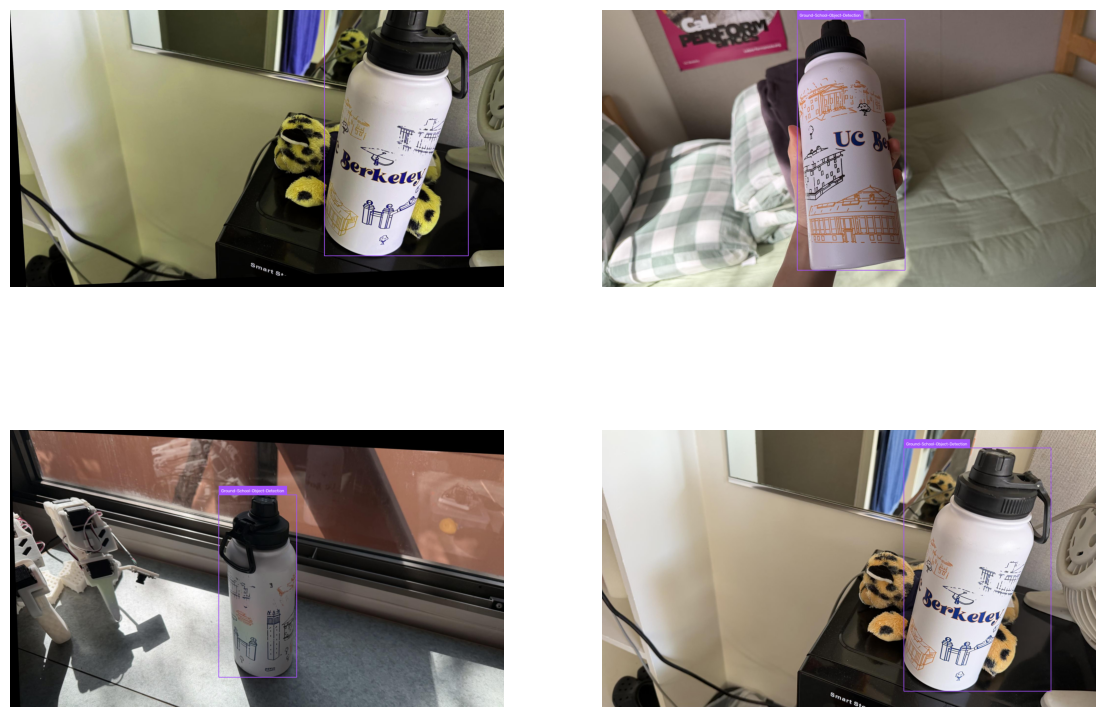

In [30]:
train_ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/train/images",
    annotations_directory_path=f"{dataset.location}/train/labels",
    data_yaml_path=DATA_YAML,
)
print(f"{len(train_ds)} training images, classes: {train_ds.classes}")

samples = []
for i, (path, image, annotations) in enumerate(train_ds):
    if i == 4:
        break
    labels = [train_ds.classes[c] for c in annotations.class_id]
    frame = box_annotator.annotate(scene=image.copy(), detections=annotations)
    frame = label_annotator.annotate(scene=frame, detections=annotations, labels=labels)
    samples.append(frame)

sv.plot_images_grid(samples, grid_size=(2, 2), size=(14, 10))

## Custom Training

We fine-tune `yolo26s`, the small variant. It is a good trade-off between accuracy and speed on a T4; swap in `yolo26n` for something faster or `yolo26m` for something more accurate.

Settings that keep this fast on Colab:

- `cache="ram"`: decode and resize every image once, then keep it in memory. The free Colab VM has only 2 CPU cores, so JPEG decoding is normally the bottleneck, not the GPU. The football dataset comfortably fits in RAM.
- `batch=16`, `imgsz=640`, `amp=True` (default): mixed precision is on automatically. Use `imgsz=800` if you care most about tiny objects like the ball; it costs ~1.5x the time.
- `epochs=25` is enough to get a clearly working model for this tutorial. For a production model train longer (100+) and let `patience` stop it early.
- `project`/`name`/`exist_ok=True` pin the output folder to `runs/football`, so re-running the cell does not create `train2`, `train3`, ... directories.

Full list of arguments: [docs.ultralytics.com/modes/train](https://docs.ultralytics.com/modes/train/#train-settings).

In [31]:
import os, random, shutil

root = dataset.location
images = sorted(os.listdir(f"{root}/train/images"))
random.Random(0).shuffle(images)
n_val = int(len(images) * 0.2)
os.makedirs(f"{root}/valid/images", exist_ok=True)
os.makedirs(f"{root}/valid/labels", exist_ok=True)
for name in images[:n_val]:
    stem = os.path.splitext(name)[0]
    shutil.move(f"{root}/train/images/{name}", f"{root}/valid/images/{name}")
    shutil.move(f"{root}/train/labels/{stem}.txt", f"{root}/valid/labels/{stem}.txt")
print(f"{n_val} images moved to valid/")

19 images moved to valid/


In [32]:
model = YOLO("yolo26s.pt")


train_results = model.train(
    data=DATA_YAML,
    epochs=25,
    imgsz=640,
    batch=16,
    cache="ram",
    project=f"{HOME}/runs",
    name=PROJECT,
    exist_ok=True,
    plots=True,
)

RUN_DIR = str(model.trainer.save_dir)
BEST_WEIGHTS = f"{RUN_DIR}/weights/best.pt"
print("run directory:", RUN_DIR)
print("best weights:", BEST_WEIGHTS)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Ground-School-Object-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ground-school-object-detection, 

Training writes a handful of useful artefacts into the run directory. The confusion matrix shows which classes get mixed up, `results.png` plots the losses and metrics per epoch, and `val_batch0_pred.jpg` is a grid of validation predictions from the last epoch.

In [33]:
!ls {RUN_DIR}

args.yaml			 results.csv	     train_batch75.jpg
BoxF1_curve.png			 results.png	     train_batch76.jpg
BoxP_curve.png			 train_batch0.jpg    train_batch77.jpg
BoxPR_curve.png			 train_batch105.jpg  val_batch0_labels.jpg
BoxR_curve.png			 train_batch106.jpg  val_batch0_pred.jpg
confusion_matrix_normalized.png  train_batch107.jpg  weights
confusion_matrix.png		 train_batch1.jpg
labels.jpg			 train_batch2.jpg


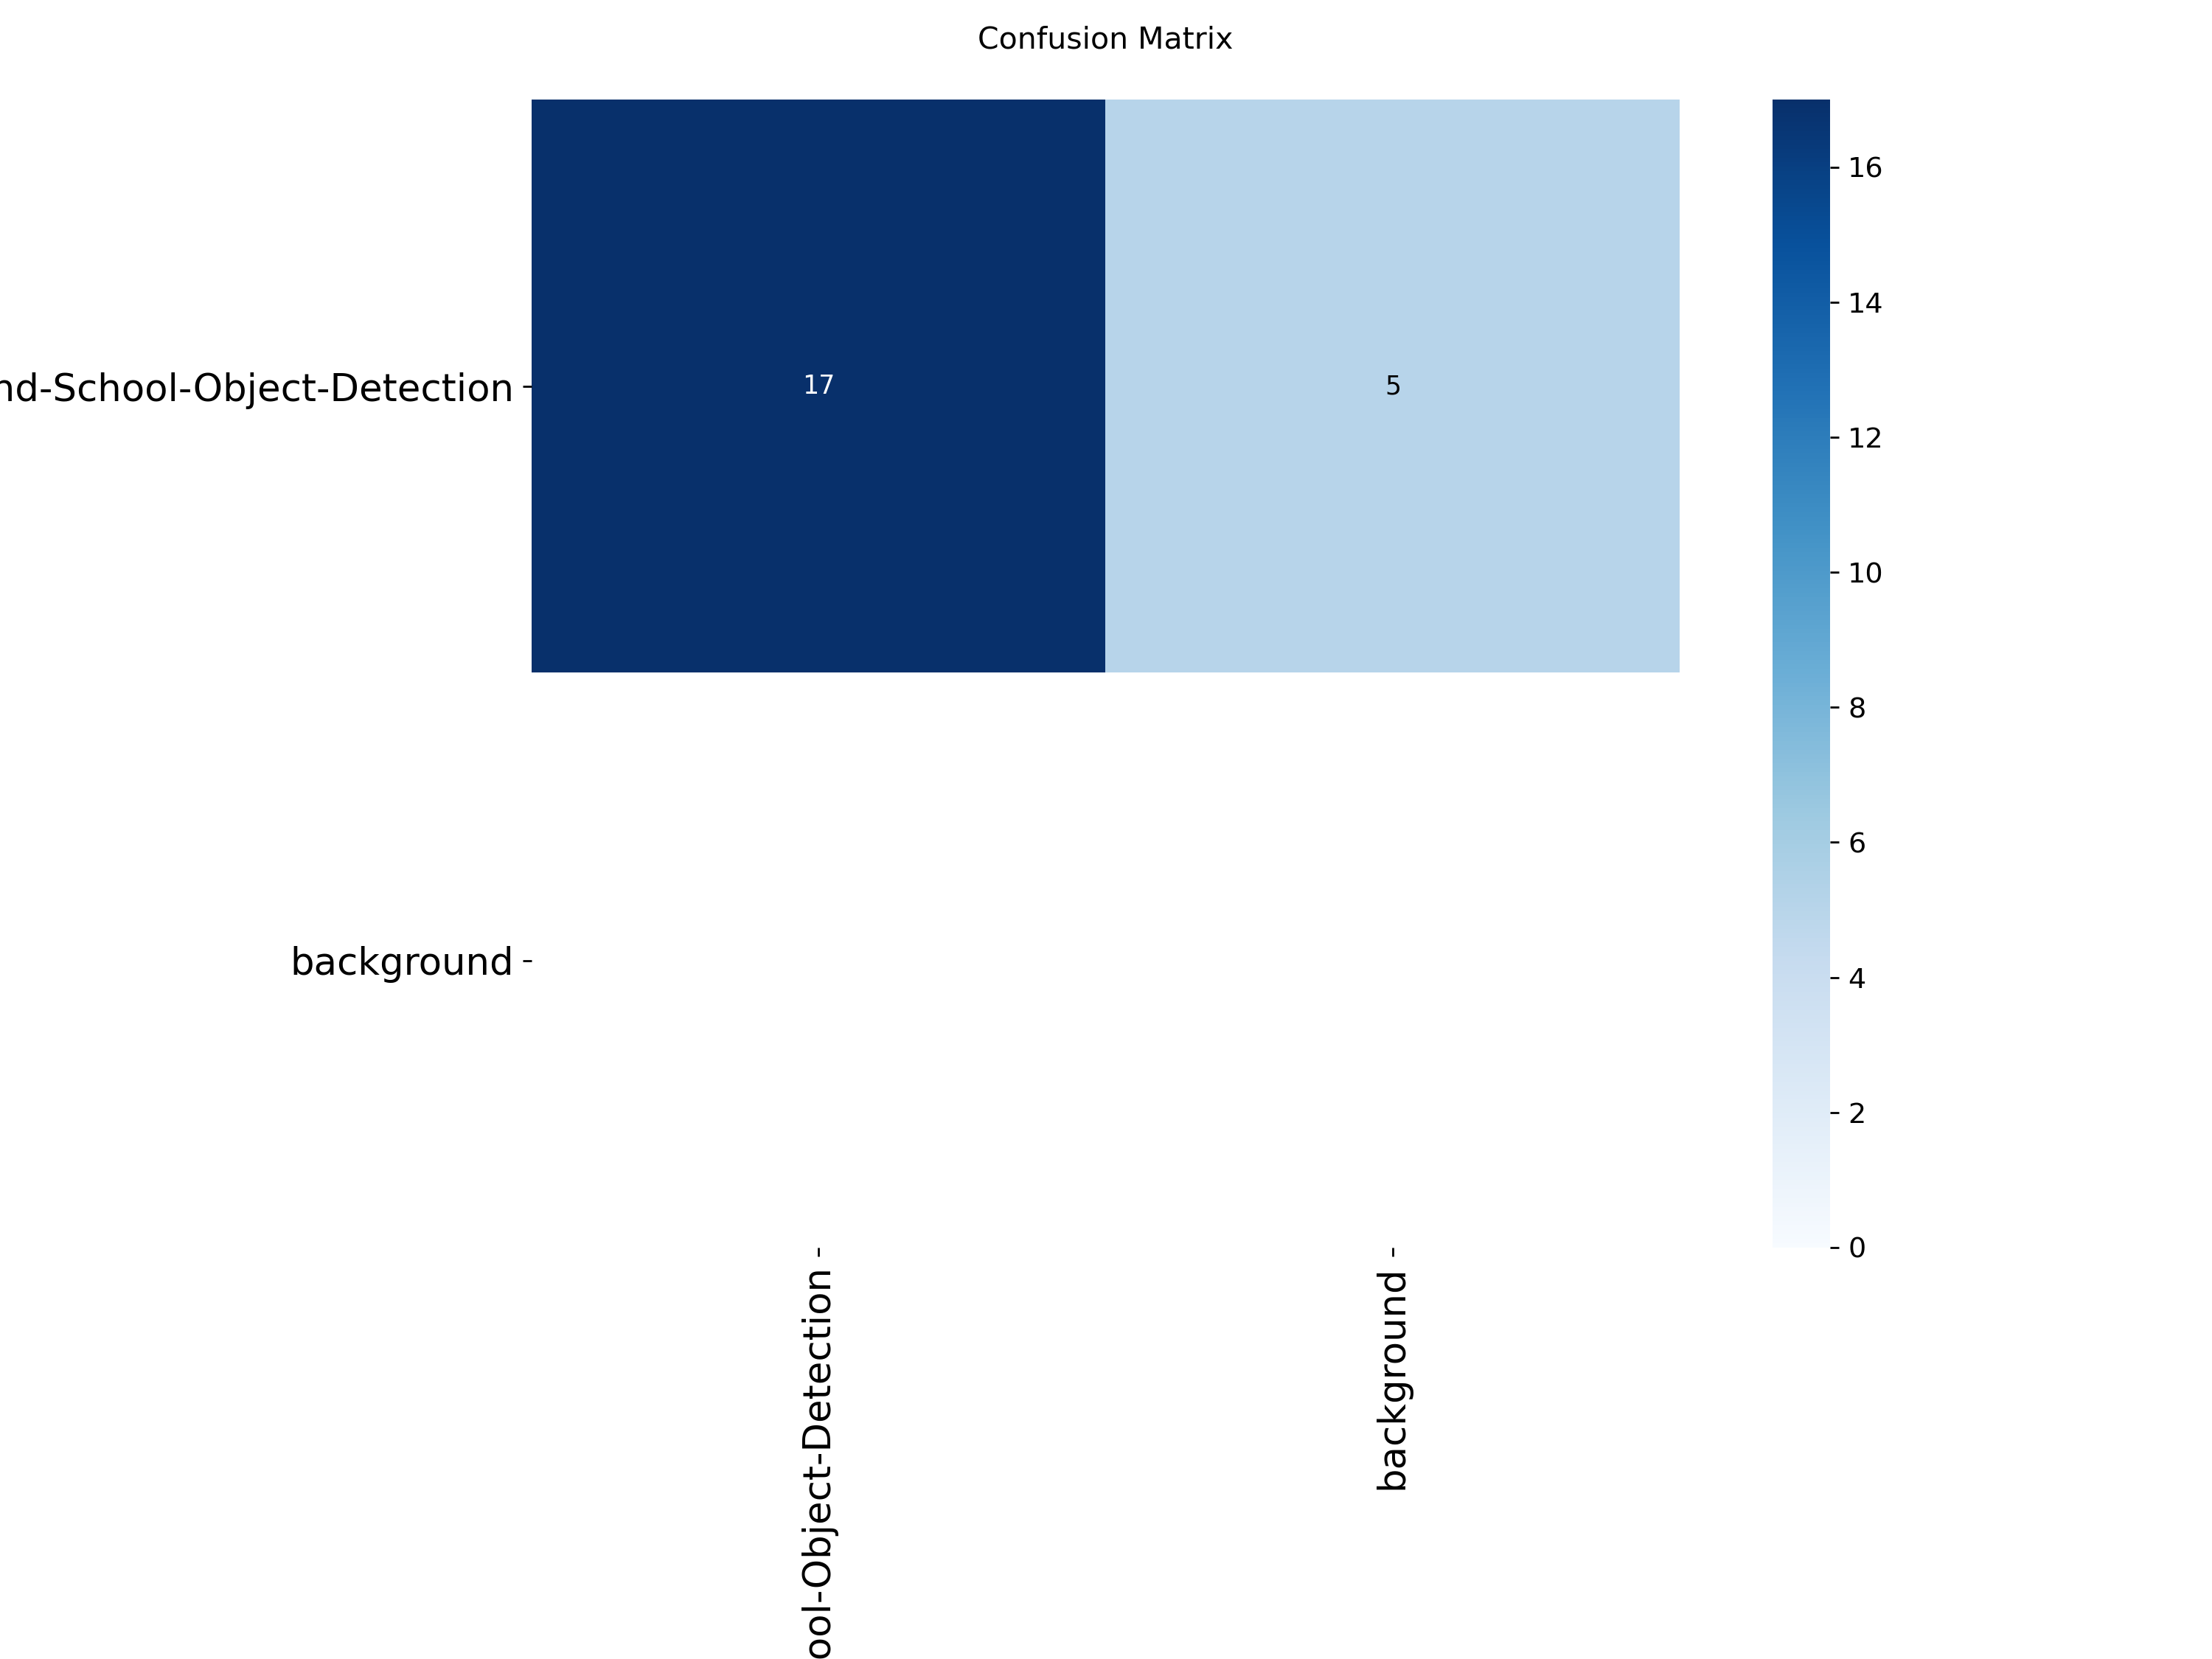

In [34]:
display(Image(filename=f"{RUN_DIR}/confusion_matrix.png", width=600))

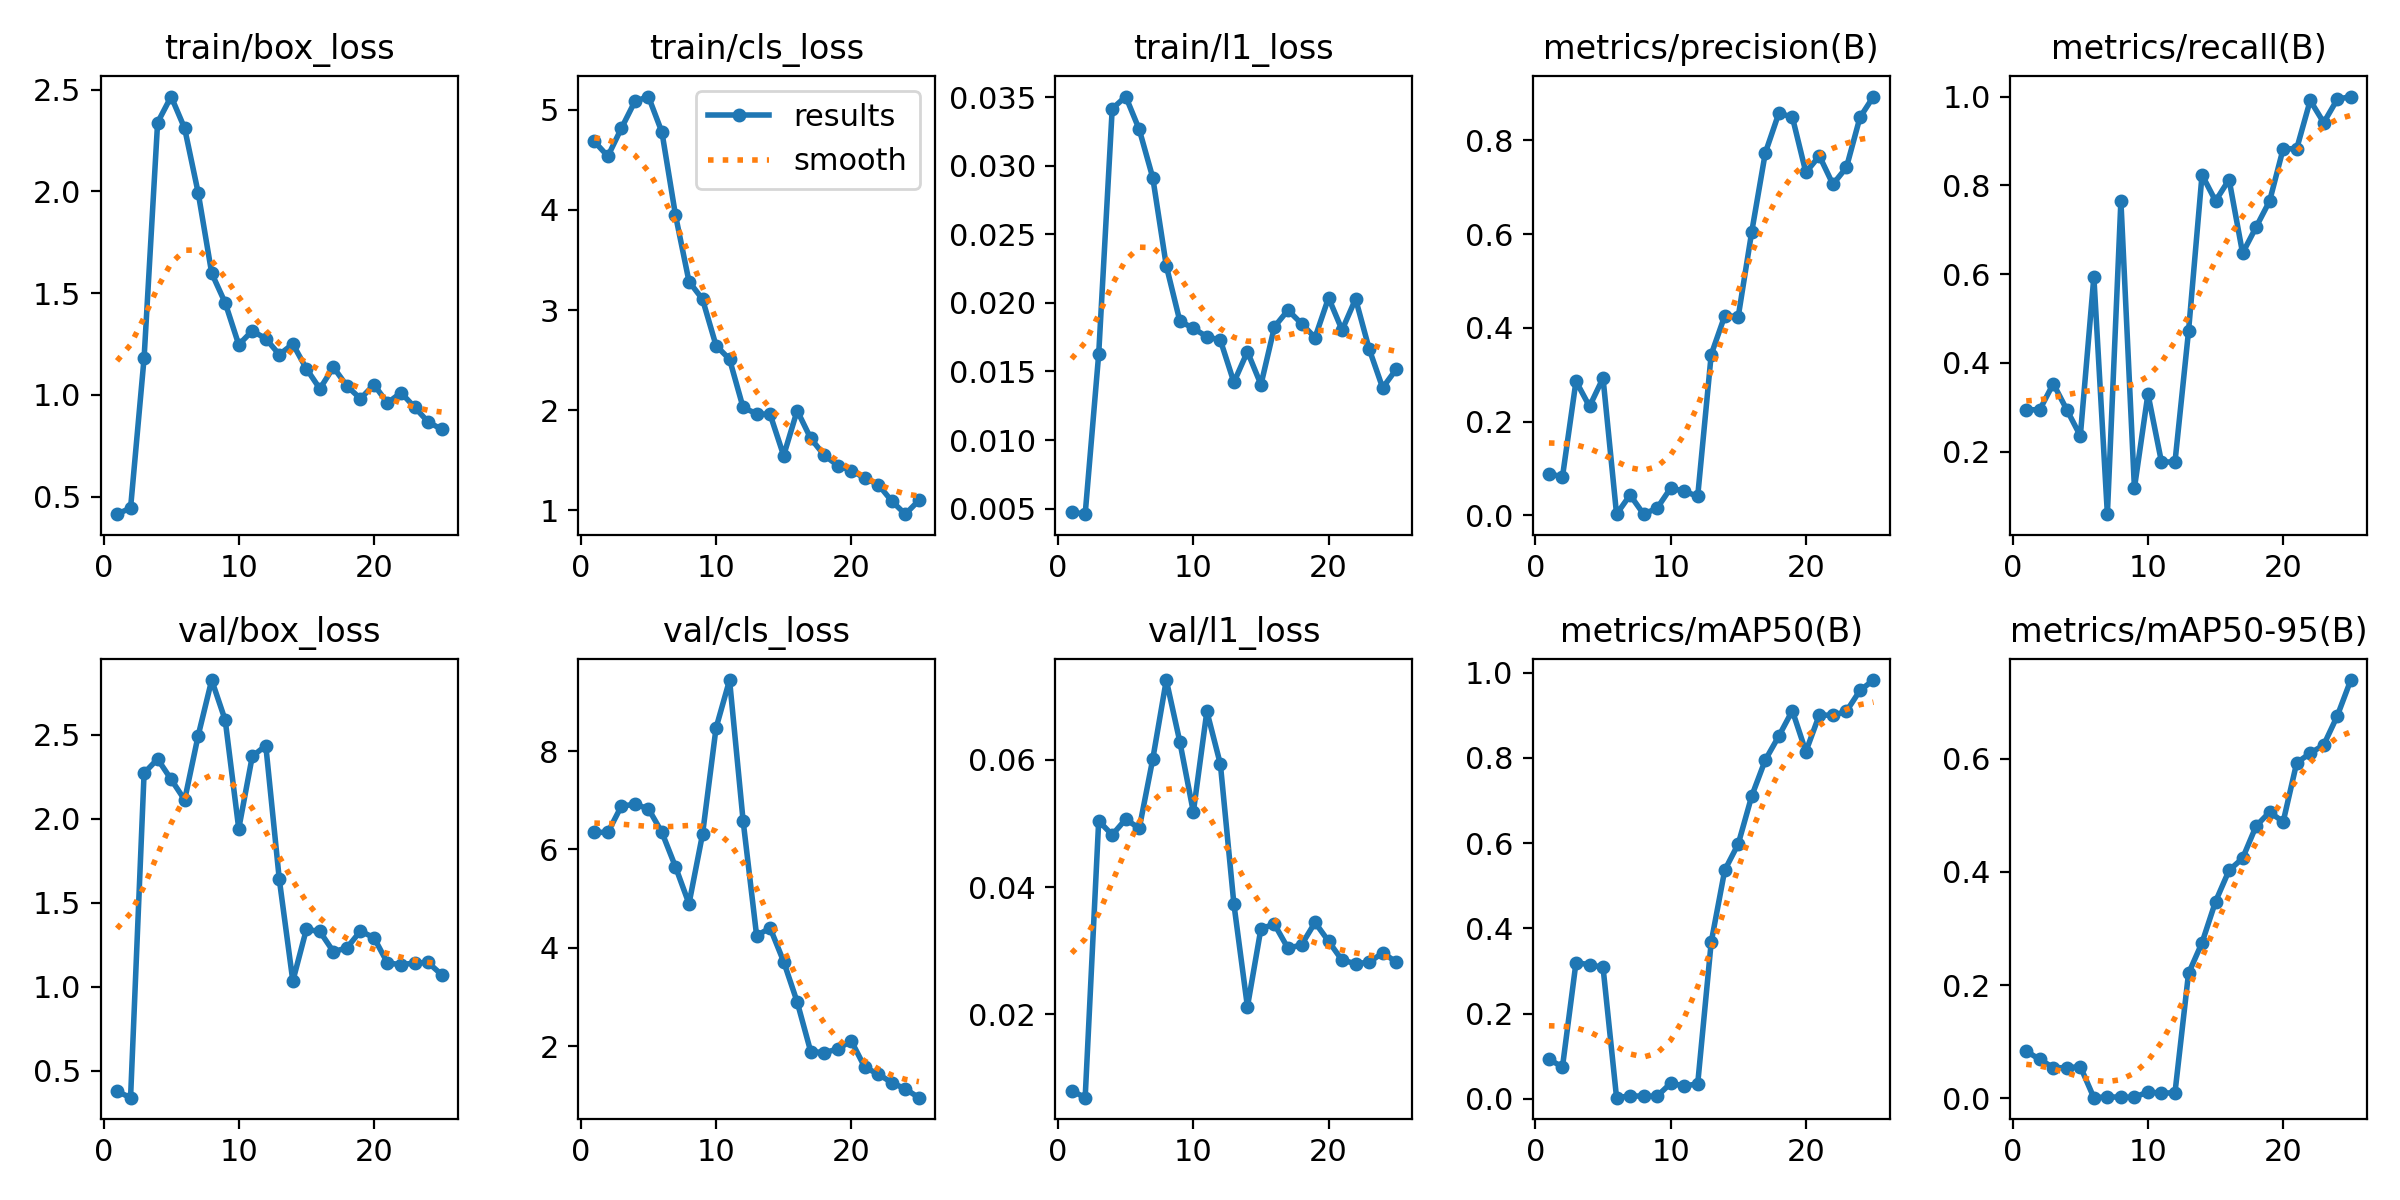

In [35]:
display(Image(filename=f"{RUN_DIR}/results.png", width=600))

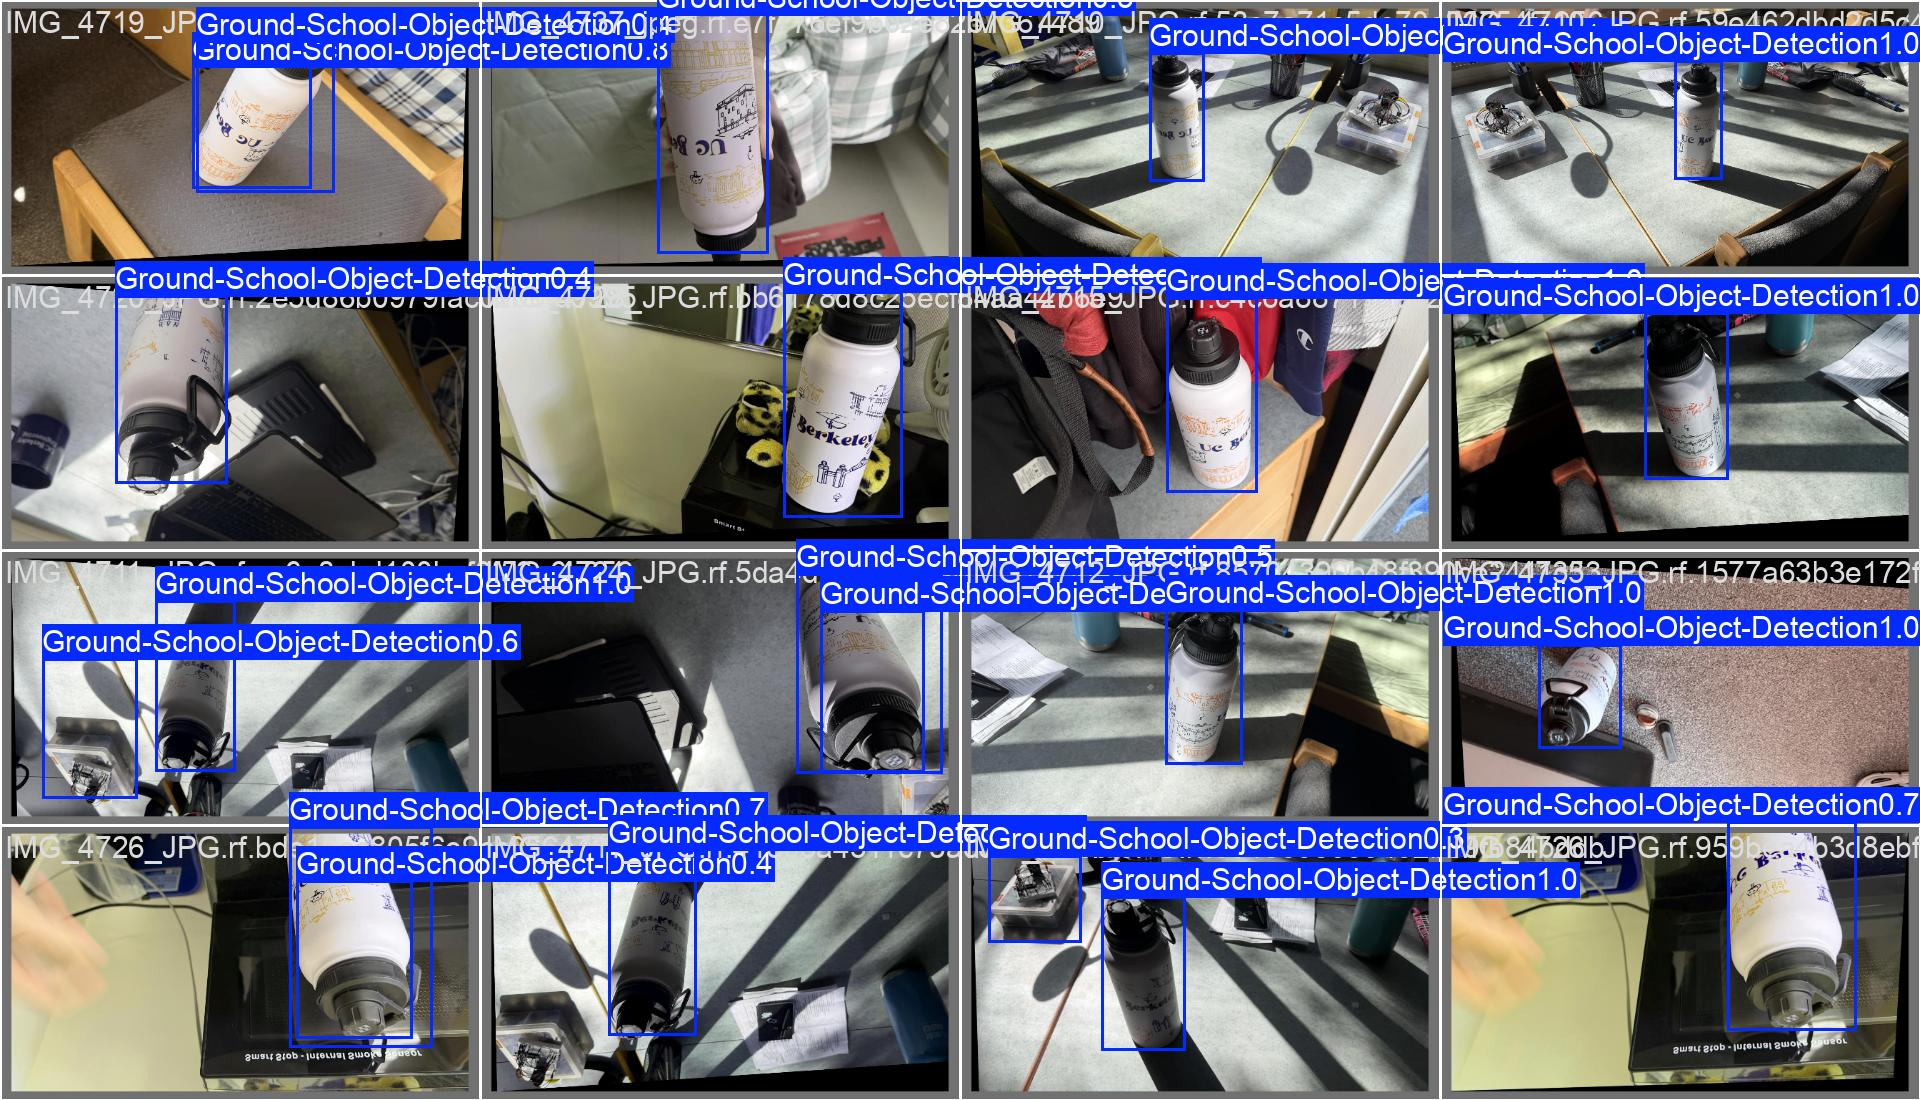

In [36]:
display(Image(filename=f"{RUN_DIR}/val_batch0_pred.jpg", width=600))

## Validate the Custom Model

Training already validates after every epoch, but `model.val()` gives you the final numbers for `best.pt` on the validation split (or the test split, with `split="test"`).
`mAP50-95` is the headline metric used by COCO; `mAP50` is more forgiving about box tightness.

In [37]:
best_model = YOLO(BEST_WEIGHTS)

metrics = best_model.val(data=DATA_YAML, imgsz=640, plots=False)

print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP75:    {metrics.box.map75:.3f}")
for i, name in best_model.names.items():
    print(f"  {name:>14}: AP50-95 = {metrics.box.maps[i]:.3f}")

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 120 layers, 9,465,567 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1907.9±234.6 MB/s, size: 172.3 KB)
val: Scanning /content/datasets/Ground-School-Object-Detection-2/valid/labels.cache... 19 images, 0 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 19/19 5.0Mit/s 0.0s
val: /content/datasets/Ground-School-Object-Detection-2/valid/images/IMG_4718_JPG.rf.cee9f545ae95910e936dabfe91edc21e.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/datasets/Ground-School-Object-Detection-2/valid/images/IMG_4718_JPG.rf.cfb312c5e84dd4daba3ac95f1527f57b.jpg: ignoring corrupt image/label: labels mix segment and detection rows
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s
                   all         17         17      0.894          1      0.983 

## Inference with the Custom Model

Run the fine-tuned model on the held-out test images. Passing a list of paths runs them as one batched call; we then annotate in memory instead of round-tripping through the disk.

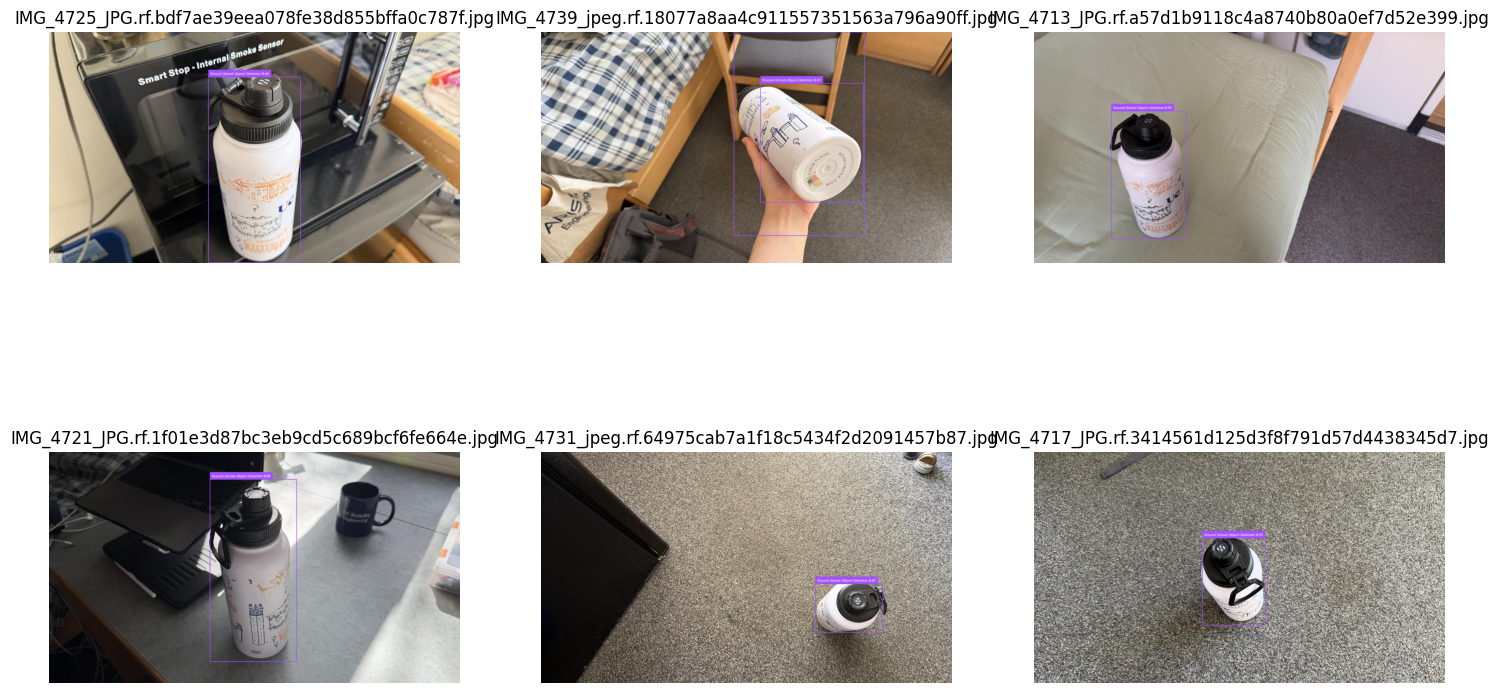

In [38]:
import glob
import random

test_images = sorted(glob.glob(f"{dataset.location}/test/images/*.jpg"))
random.seed(0)
sample_paths = random.sample(test_images, k=min(6, len(test_images)))

results = best_model.predict(source=sample_paths, conf=0.25, imgsz=640, verbose=False)

sv.plot_images_grid(
    [annotate(r) for r in results],
    grid_size=(2, 3),
    titles=[os.path.basename(r.path) for r in results],
    size=(18, 10),
)

Detections are also available as plain Python objects, handy for feeding into your own logic:

In [39]:
results[0].summary()

[{'name': 'Ground-School-Object-Detection',
  'class': 0,
  'confidence': 0.48016,
  'box': {'x1': 794.78339,
   'y1': 224.49199,
   'x2': 1253.93152,
   'y2': 1150.94165}}]

## OPTIONAL: Deploy the Model on Roboflow

Once you're happy with the model, upload `best.pt` to Roboflow so it runs on their serverless API (and can be pulled down to edge devices later).
`version.deploy()` packages the weights, checks that the model type matches the project, and uploads them.

`model_type` must include the size suffix (`yolo26n`, `yolo26s`, ...). `model_path` is the run directory, which must contain `weights/best.pt`.

⚠️ This only works for a version in **your own** workspace, so it will fail on the public `model-examples` dataset used above. Fork the dataset on Universe (or use your own project), set `WORKSPACE`/`PROJECT`/`VERSION` at the top, re-run the download and training cells, and then run this.

In [ ]:
version.deploy(model_type="yolo26s", model_path=RUN_DIR)

It takes a couple of minutes for the deployment to become live. You can follow progress on the version's *Deploy* tab in the Roboflow dashboard.

### Run inference on the hosted API

Re-fetching the version after deployment gives us a `model` handle for the serverless API. It is `None` until the deployment has finished processing, so wait a minute and re-run if the assertion fails.
`confidence` and `overlap` are percentages here, unlike the 0-1 floats Ultralytics uses. The JSON response converts straight into a `supervision.Detections` object.

(On your own machine you can also use [`inference-sdk`](https://inference.roboflow.com/inference_helpers/inference_sdk/), the newer client. We skip it in Colab because of the Pillow conflict described in the install section.)

In [ ]:
import cv2

hosted_model = project.version(VERSION).model
assert hosted_model is not None, "Deployment is still processing. Wait a minute and re-run this cell."

image_path = random.choice(test_images)
image = cv2.imread(image_path)

response = hosted_model.predict(image_path, confidence=25, overlap=30).json()
detections = sv.Detections.from_inference(response)
print(f"{len(detections)} detections from the hosted model on {os.path.basename(image_path)}")

labels = [f"{name} {conf:.2f}" for name, conf in zip(detections["class_name"], detections.confidence)]
frame = box_annotator.annotate(scene=image.copy(), detections=detections)
frame = label_annotator.annotate(scene=frame, detections=detections, labels=labels)
sv.plot_image(frame, size=(10, 8))

## Deploy the Model to the Edge

In addition to the hosted API, you can run your deployed model on your own hardware with [Roboflow Inference](https://inference.roboflow.com), an open-source inference server that works on CPUs, NVIDIA GPUs, Jetson devices and Raspberry Pi.

### Option 1: run the model in-process with the `inference` package

```bash
pip install inference        # add [gpu] on a CUDA machine: pip install "inference[gpu]"
```

```python
import cv2
import supervision as sv
from inference import get_model

model = get_model(model_id="football-players-obj-detection/2", api_key="YOUR_ROBOFLOW_API_KEY")

image = cv2.imread("frame.jpg")
result = model.infer(image, confidence=0.25)[0]
detections = sv.Detections.from_inference(result)
```

The weights are downloaded once and cached on the device, so it keeps working offline afterwards.

### Option 2: run a local inference server with Docker

```bash
# CPU
docker run -it --rm -p 9001:9001 roboflow/roboflow-inference-server-cpu

# NVIDIA GPU
docker run -it --rm --gpus all -p 9001:9001 roboflow/roboflow-inference-server-gpu
```

Then talk to it with `inference-sdk` (`pip install inference-sdk`; on your own machine the Pillow conflict does not apply):

```python
from inference_sdk import InferenceHTTPClient

client = InferenceHTTPClient(api_url="http://localhost:9001", api_key="YOUR_ROBOFLOW_API_KEY")
response = client.infer("frame.jpg", model_id="football-players-obj-detection/2")
```

### Option 3: export the weights and skip Roboflow entirely

Ultralytics can export the model to ONNX, TensorRT, CoreML, TFLite, OpenVINO and more for use in your own application:

```python
best_model.export(format="onnx", imgsz=640)        # -> runs/football/weights/best.onnx
best_model.export(format="engine", half=True)      # TensorRT, run this on the target GPU
```

See [docs.ultralytics.com/modes/export](https://docs.ultralytics.com/modes/export/) for all formats.

## 🏆 Congratulations

### Learning Resources

- [Ultralytics YOLO26 docs](https://docs.ultralytics.com/models/yolo26/): architecture, benchmarks, all train/predict/export arguments.
- [Roboflow Notebooks](https://github.com/roboflow/notebooks): dozens of notebooks that walk through training and using models, from YOLO to RF-DETR to vision-language models.
- [supervision docs](https://supervision.roboflow.com): annotators, trackers, zone counting, dataset utilities and metrics.
- [Roboflow Inference docs](https://inference.roboflow.com): self-hosting, Workflows, video streams and edge devices.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): video tutorials that accompany the notebooks.
- [Roboflow Discuss](https://discuss.roboflow.com/): ask questions and share what you have built.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.